In [1]:
import os
import parse_labels
import dataset
import util

import importlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
import model
import importlib

importlib.reload(parse_labels)

# gets the labels
base_path = os.getcwd()
input_path = "raw_data/manifest-xxn3N2Qq630907925598003437/TCGA-KIRC"
all_dirs = os.listdir(input_path)


label_path = os.path.join(base_path, "raw_data", "labels.txt")
data_path = os.path.join(base_path, "raw_data", "manifest-xxn3N2Qq630907925598003437/TCGA-KIRC")

map = parse_labels.get_all_dcm_files(label_path, data_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [2]:
importlib.reload(model)

# Get patient scan series data (grouped by patient AND scan series)
series_data = parse_labels.get_all_dcm_files(label_path, data_path)
print(f"Found {len(series_data)} scan series total\n")
DATA_SHAPE = (64, 192, 192)

Found 2652 scan series total



In [3]:
importlib.reload(util)
import math
# Preload scan series volumes into memory

DATA_SHAPE = (64, 192, 192)
print("Preloading scan series volumes...")
preloaded_data = util.preload_dcm_files(
    series_data, 
    crop=(100 * (1 - 1/math.sqrt(2)), 100 * (1 - 1/math.sqrt(2)), 0),
    target_shape=DATA_SHAPE,  # (Depth, Height, Width)
    max_files=None   # Start with small subset to test
)
print(f"Successfully preloaded {len(preloaded_data)} scan series volumes")


# Print grade count for each label
grade_counts = {}
for _, label, _ in preloaded_data.values():
    lbl = label.item()
    grade_counts[lbl] = grade_counts.get(lbl, 0) + 1

print("\nGrade count by label:")
for lbl in sorted(grade_counts.keys()):
    print(f"  Label {lbl} (Grade {lbl + 1}): {grade_counts[lbl]} samples")

Preloading scan series volumes...


Preloading Scan Series:  71%|███████   | 1883/2652 [14:49<06:03,  2.12series/s] 

Successfully preloaded 1883 scan series volumes

Grade count by label:
  Label 0 (Grade 1): 16 samples
  Label 1 (Grade 2): 787 samples
  Label 2 (Grade 3): 788 samples
  Label 3 (Grade 4): 292 samples


In [ ]:
from skimage import exposure
from scipy.ndimage import laplace
from tqdm import tqdm
import numpy as np
import torch
import os

# Process each scan volume
for key, (volume, label, patient_id) in tqdm(preloaded_data.items(), desc="Processing scan volumes"):
    # Extract top-left 3x3x3 cube and compute average brightness
    cube = volume[0, 0:3, 0:3, 0:3]
    avg_brightness = torch.mean(cube).item()
    
    # Invert if average brightness > 128
    if avg_brightness >= 128:
        volume = 256 - volume
    
    processed_volume = volume.float()
    
    # Normalize to 0-1 range for skimage processing
    if processed_volume.max() > 0:
        processed_volume = processed_volume / processed_volume.max()
    
    # Convert to numpy and remove channel dimension [1, D, H, W] -> [D, H, W]
    processed_volume_np = processed_volume[0].cpu().numpy()
    
    # 1. Laplacian Sharpening
    lap = laplace(processed_volume_np)
    sharpened_volume = processed_volume_np - 0.3 * lap
    
    # 2. Histogram Equalization
    equalized_volume = exposure.equalize_hist(sharpened_volume)
    
    # Add the channel dimension back
    final_volume_np = np.expand_dims(equalized_volume, axis=0)
    
    # Convert back to tensor and 0-255 range
    final_volume = torch.from_numpy(final_volume_np).float() * 255

    preloaded_data[key] = (final_volume, label, patient_id)
    #preloaded_data[key] = (processed_volume, label, patient_id)

# Save the preprocessed data directly
save_path = os.path.join(base_path, "preloaded_data_processed.pt")
print(f"Saving preprocessed data to {save_path}...")
torch.save(preloaded_data, save_path)
print("Data successfully saved.")

Processing scan volumes:   0%|          | 0/1883 [00:00<?, ?it/s]

Processing scan volumes: 100%|██████████| 1883/1883 [00:00<00:00, 34296.39it/s]


Saving preprocessed data to /home/petedowney/github/KidneyCancerPrediction/preloaded_data_processed.pt...
Data successfully saved.


In [ ]:
# save_path = os.path.join(base_path, "preloaded_data_processed.pt")
# preloaded_data = torch.load(save_path)

/tmp/ipykernel_16659/1216294515.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  preloaded_data = torch.load(save_path)


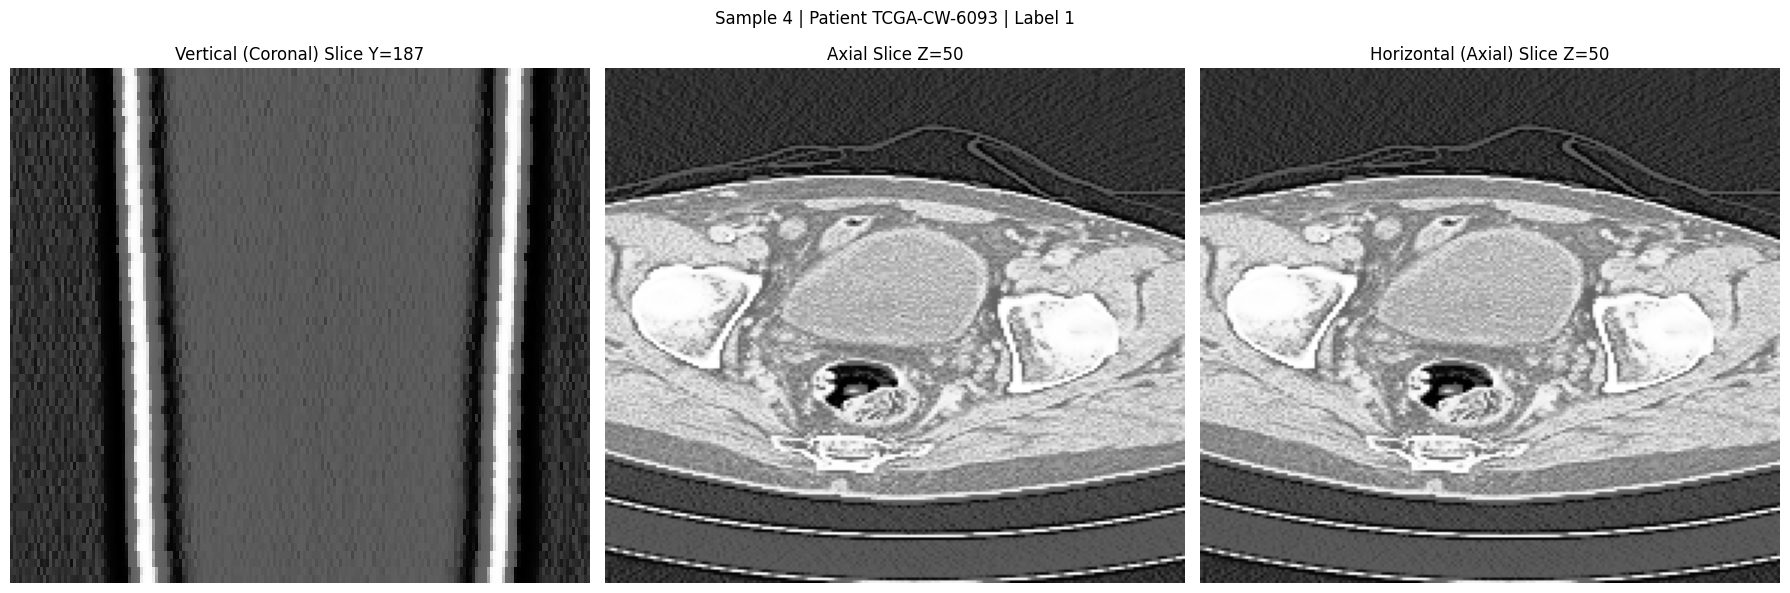

In [5]:
import matplotlib.pyplot as plt

# Pick a random preloaded scan and display slices
sample_idx = np.random.choice(list(preloaded_data.keys()))
volume, label, patient_id = preloaded_data[sample_idx]

# volume shape is expected to be [C, D, H, W] matches [C, Z, Y, X]
depth, height, width = volume.shape[1], volume.shape[2], volume.shape[3]

slice_idx_z = np.random.randint(0, depth)   # Horizontal (Axial) plane slice
slice_idx_y = np.random.randint(0, height)  # Vertical (Coronal) plane slice

vol_np = volume[0].cpu().numpy()

# Note on dimensions:
# vol_np is shaped [Z, Y, X] (Depth, Height, Width)

# Vertical (Coronal) plane: fix Y, plot Z vs X
show_img_one = vol_np[:, slice_idx_y, :]

# "Sharpened" (Axial) plane: fix Z, plot Y vs X 
show_img_two = vol_np[slice_idx_z, :, :]

# Horizontal (Axial) plane: fix Z, plot Y vs X
slice_img_horizontal = vol_np[slice_idx_z, :, :]

# Scale visuals for displaying
show_img_one = (show_img_one - show_img_one.min()) / (show_img_one.max() - show_img_one.min() + 1e-8)
show_img_two = (show_img_two - show_img_two.min()) / (show_img_two.max() - show_img_two.min() + 1e-8)
slice_img_horizontal = (slice_img_horizontal - slice_img_horizontal.min()) / (slice_img_horizontal.max() - slice_img_horizontal.min() + 1e-8)

# w1 is Width (X). w2 is the Height (Z-axis scale in the Coronal plane)
# show_img_horizontal shape is [Y, X], show_img_one shape is [Z, X]
w_axial = slice_img_horizontal.shape[1] # X dimension
w_coronal = show_img_one.shape[1] # X dimension
# For proper subplot aspect ratios based on image widths:
w1, w2 = w_axial, w_coronal

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [w_coronal, w_axial, w_axial]})

# 1. Vertical Coronal (Z vs X) -> Extent is narrow vertically because Z is 64, X is 256
axes[0].imshow(show_img_one, cmap="gray", aspect='auto')
axes[0].set_title(f"Vertical (Coronal) Slice Y={slice_idx_y}")
axes[0].axis("off")

# 2. Sharpened Axial (Y vs X) -> 256x256 square
axes[1].imshow(show_img_two, cmap="gray", aspect='auto')
axes[1].set_title(f"Axial Slice Z={slice_idx_z}")
axes[1].axis("off")

# 3. Standard Axial (Y vs X) -> 256x256 square
axes[2].imshow(slice_img_horizontal, cmap="gray", aspect='auto')
axes[2].set_title(f"Horizontal (Axial) Slice Z={slice_idx_z}")
axes[2].axis("off")

plt.suptitle(f"Sample {sample_idx} | Patient {patient_id} | Label {label.item() + 1}")
plt.tight_layout()
plt.show()

In [ ]:
importlib.reload(dataset)
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.ndimage

def augment_data(data_dict, series_dict):
    # Find which label has the max amount of samples
    counts = {}
    for _, label, _ in data_dict.values():
        lbl = label.item()
        counts[lbl] = counts.get(lbl, 0) + 1

    target_count = max(counts.values())
    print(f"Augmenting minority labels to target count: {target_count}")

    aug_data = data_dict.copy()
    aug_series = series_dict.copy()
    
    new_idx = max(data_dict.keys()) + 1 if data_dict else 0

    for label_to_augment, current_count in counts.items():
        # skip the first output label of 1 (which internally maps to label index 0)
        if label_to_augment == 0:
            continue

        if current_count < target_count:
            needed = target_count - current_count
            class_keys = [k for k, v in data_dict.items() if v[1].item() == label_to_augment]

            # Randomly oversample the data to match target exactly
            augmented_keys = np.random.choice(class_keys, size=needed, replace=True)

            for aug_key in augmented_keys:
                volume, label, patient_id = data_dict[aug_key]
                
                # Apply 3D data augmentation with slight rotations/translations
                vol_np = volume.cpu().numpy()
                
                # Random rotation (-10 to 10 degrees) along Z and Y axes
                angle_z = np.random.uniform(-10, 10)
                angle_y = np.random.uniform(-10, 10)
                # Random translation (-3 to 3 voxels) in depth, height, width
                shift_vals = np.random.uniform(-3, 3, size=3)
                # vol_np has shape [C, D, H, W] (e.g. 4 dimensions), so shift needs length 4
                shift_vals_4d = [0, shift_vals[0], shift_vals[1], shift_vals[2]]
                
                # Apply transformations
                # axes=(2, 3) to rotate in the H/W plane
                vol_aug = scipy.ndimage.rotate(vol_np, angle_z, axes=(2, 3), reshape=False, order=1, mode='nearest')
                vol_aug = scipy.ndimage.shift(vol_aug, shift_vals_4d, order=1, mode='nearest')
                
                volume_aug_tensor = torch.from_numpy(vol_aug).to(volume.device)
                
                aug_data[new_idx] = (volume_aug_tensor, label, f"{patient_id}_aug")
                if aug_key in series_dict:
                    aug_series[new_idx] = series_dict[aug_key]
                new_idx += 1

    return aug_data, aug_series


def print_label_distribution(data_dict, title="Label distribution"):
    counts = {}
    for _, label, _ in data_dict.values():
        lbl = label.item()
        counts[lbl] = counts.get(lbl, 0) + 1

    print(f"{title}:")
    for lbl in sorted(counts.keys()):
        print(f"  Label {lbl} (Grade {lbl + 1}): {counts[lbl]} samples")

# Convert preloaded data to uint8 before splitting
to_uint8_data = {}
for key, (vol, lbl, pid) in preloaded_data.items():
    uint8_vol = (vol * 255).to(torch.uint8)
    to_uint8_data[key] = (uint8_vol, lbl, pid)

# Align the data items using their keys
keys = list(to_uint8_data.keys())
series_items = [(k, series_data[k]) for k in keys]
data_items = [(k, to_uint8_data[k]) for k in keys]

# Data splits
train_series_items, temp_series_items, train_data_items, temp_data_items = train_test_split(
    series_items, data_items, test_size=0.4, random_state=42
)

val_series_items, test_series_items, val_data_items, test_data_items = train_test_split(
    temp_series_items, temp_data_items, test_size=0.5, random_state=43
)

train_series = {i: item[1] for i, item in enumerate(train_series_items)}
val_series = {i: item[1] for i, item in enumerate(val_series_items)}
test_series = {i: item[1] for i, item in enumerate(test_series_items)}

train_data = {i: item[1] for i, item in enumerate(train_data_items)}
val_data = {i: item[1] for i, item in enumerate(val_data_items)}
test_data = {i: item[1] for i, item in enumerate(test_data_items)}

print(f"Train scan series before augmentation: {len(train_series)}")
print(f"Val scan series: {len(val_series)}")
print(f"Test scan series: {len(test_series)}")

# Augment the training data
#train_data, train_series = augment_data(train_data, train_series)

print(f"Train scan series after augmentation: {len(train_series)}\n")
print_label_distribution(train_data, title="Train Label Distribution")
print_label_distribution(val_data, title="Validation Label Distribution")
print_label_distribution(test_data, title="Test Label Distribution")

# Use the train/val split inputs directly in the DCMDataset
train_dataset = dataset.DCMDataset(train_series, DATA_SHAPE, preloaded_data=train_data)
val_dataset = dataset.DCMDataset(val_series, DATA_SHAPE, preloaded_data=val_data)
test_dataset = dataset.DCMDataset(test_series, DATA_SHAPE, preloaded_data=test_data)

print(f"Train dataset size: {train_dataset.print_memory_usage() / (1024**2):.2f} MB")
print(f"Validation dataset size: {val_dataset.print_memory_usage() / (1024**2):.2f} MB")
print(f"Test dataset size: {test_dataset.print_memory_usage() / (1024**2):.2f} MB")

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=2, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=2, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=2, shuffle=False, num_workers=2, pin_memory=True
)

# Check dataset sizes
print(f"Train dataset length: {len(train_dataset)}")
print(f"Val dataset length: {len(val_dataset)}")
print(f"Test dataset length: {len(test_dataset)}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches per epoch: {len(val_loader)}")

Train scan series before augmentation: 1129
Val scan series: 377
Test scan series: 377
Train scan series after augmentation: 1129

Train Label Distribution:
  Label 0 (Grade 1): 12 samples
  Label 1 (Grade 2): 480 samples
  Label 2 (Grade 3): 470 samples
  Label 3 (Grade 4): 167 samples
Validation Label Distribution:
  Label 0 (Grade 1): 2 samples
  Label 1 (Grade 2): 152 samples
  Label 2 (Grade 3): 170 samples
  Label 3 (Grade 4): 53 samples
Test Label Distribution:
  Label 0 (Grade 1): 2 samples
  Label 1 (Grade 2): 155 samples
  Label 2 (Grade 3): 148 samples
  Label 3 (Grade 4): 72 samples
Train dataset size: 2540.32 MB
Validation dataset size: 848.27 MB
Test dataset size: 848.27 MB
Train dataset length: 1129
Val dataset length: 377
Test dataset length: 377
Train batches per epoch: 565
Val batches per epoch: 189


In [6]:
importlib.reload(model)

# Initialize model
net = model.SimpleCNN(num_classes=4, input_shape=DATA_SHAPE).to(device)

print(f"Model parameter memory usage: {net.print_memory_usage() / (1024**2):.2f} MB")

data_mem = train_dataset.print_memory_usage() + val_dataset.print_memory_usage()
model_mem = net.print_memory_usage()

print(f"Total memory usage: {model_mem / (1024**2) + data_mem / (1024**2):.2f} MB")
# Train the model
history = net.train_model(
    train_loader, 
    val_loader, 
    device, 
    num_epochs=15, 
    learning_rate=0.001,
    weight_decay=0
)

Model parameter memory usage: 4.23 MB
Total memory usage: 3392.83 MB


Epoch 1/15 Val: 100%|██████████| 189/189 [00:35<00:00,  5.33batch/s]


Train Loss: 1.1874 | Train Acc: 41.19% | Val Loss: 1.0189 | Val Acc: 47.75%


Epoch 2/15 Val: 100%|██████████| 189/189 [00:30<00:00,  6.14batch/s]


Train Loss: 1.1028 | Train Acc: 45.00% | Val Loss: 1.0205 | Val Acc: 42.97%


...

Train Loss: 0.5683 | Train Acc: 75.11% | Val Loss: 1.0503 | Val Acc: 55.97%


Epoch 14/15 Val: 100%|██████████| 189/189 [00:28<00:00,  6.70batch/s]


Train Loss: 0.5268 | Train Acc: 76.09% | Val Loss: 0.9627 | Val Acc: 63.66%


Epoch 15/15 Val: 100%|██████████| 189/189 [00:27<00:00,  6.77batch/s]

Train Loss: 0.4554 | Train Acc: 80.96% | Val Loss: 1.0230 | Val Acc: 63.93%
Training complete!


In [10]:
print(f"Total memory usage: {model_mem / (1024**2) + data_mem / (1024**2):.2f} MB")
# Train the model
history2 = net.train_model(
    train_loader, 
    val_loader, 
    device, 
    num_epochs=5, 
    learning_rate=0.001,
    weight_decay=0
)

Total memory usage: 3392.83 MB


Epoch 1/5 Val: 100%|██████████| 189/189 [00:28<00:00,  6.73batch/s]


Train Loss: 0.4271 | Train Acc: 81.93% | Val Loss: 1.0575 | Val Acc: 67.11%


Epoch 2/5 Val: 100%|██████████| 189/189 [00:28<00:00,  6.71batch/s]


Train Loss: 0.3862 | Train Acc: 83.79% | Val Loss: 1.2124 | Val Acc: 61.54%


...

Train Loss: 0.3374 | Train Acc: 87.60% | Val Loss: 1.1914 | Val Acc: 65.78%


Epoch 4/5 Val: 100%|██████████| 189/189 [00:27<00:00,  6.89batch/s]


Train Loss: 0.3296 | Train Acc: 87.42% | Val Loss: 1.2974 | Val Acc: 62.07%


Epoch 5/5 Val: 100%|██████████| 189/189 [00:31<00:00,  5.97batch/s]

Train Loss: 0.2663 | Train Acc: 90.35% | Val Loss: 1.2324 | Val Acc: 66.31%
Training complete!


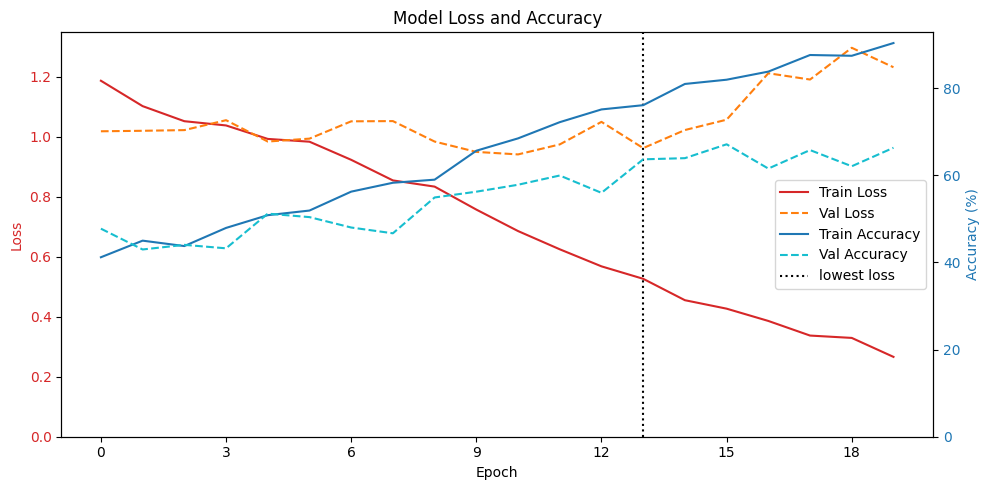

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Plot training and validation metrics on the same figure with twin y-axes
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
line1 = ax1.plot(np.append(history['train_loss'], history2['train_loss']), color='tab:red', label='Train Loss', linestyle='-')
line2 = ax1.plot(np.append(history['val_loss'], history2['val_loss']), color='tab:orange', label='Val Loss', linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# Make loss y-axis start at zero and force x-axis ticks to be integers
ax1.set_ylim(bottom=0)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# Draw a vertical line at epoch 13 (epochs are on the x-axis)
line5 = [ax1.axvline(x=13, color='black', linestyle=':', label='lowest loss')]

ax2 = ax1.twinx() 
color = 'tab:blue'
ax2.set_ylabel('Accuracy (%)', color=color)
line3 = ax2.plot(np.append(history['train_acc'], history2['train_acc']), color='tab:blue', label='Train Accuracy', linestyle='-')
line4 = ax2.plot(np.append(history['val_acc'], history2['val_acc']), color='tab:cyan', label='Val Accuracy', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Make accuracy y-axis start at zero
ax2.set_ylim(bottom=0)

# Combine legends from both axes
lines = line1 + line2 + line3 + line4 + line5
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Model Loss and Accuracy')
fig.tight_layout()
plt.show()

In [ ]:
import gc
import torch

if device.type == 'cuda':
    gc.collect()
    torch.cuda.empty_cache()

/tmp/ipykernel_20707/3796945640.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(model_path))


Training Metrics:
  Accuracy: 0.9017
  F1-Score (Macro): 0.9185
  AUROC: 0.9856

Validation Metrics:
  Accuracy: 0.6711
  F1-Score (Macro): 0.6987
  AUROC: 0.8425

Test Metrics:
  Accuracy: 0.6101
  F1-Score (Macro): 0.6551
  AUROC: 0.8049



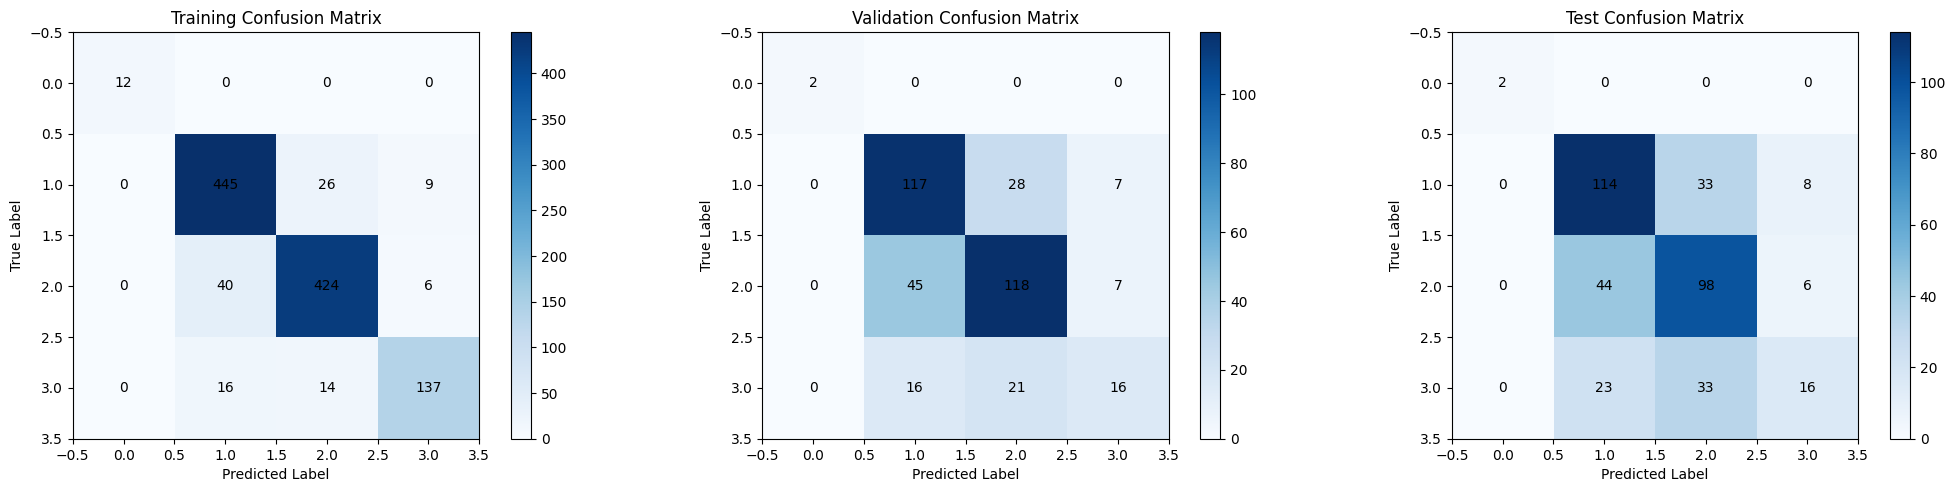

: 

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

net = model.SimpleCNN(num_classes=4, input_shape=DATA_SHAPE).to(device)
model_path = os.path.join(base_path, "model2_epoch0.pth")
net.load_state_dict(torch.load(model_path))

# Get predictions for training data
train_preds = []
train_true = []
train_probs = []
net.eval()
with torch.no_grad():
    for images, labels, _ in train_loader:
        images = images.to(device)
        outputs = net(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_probs.extend(probs.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

# Get predictions for validation data
val_preds = []
val_true = []
val_probs = []
with torch.no_grad():
    for images, labels, _ in val_loader:
        images = images.to(device)
        outputs = net(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_probs.extend(probs.cpu().numpy())
        val_true.extend(labels.cpu().numpy())

# Get predictions for test data
test_preds = []
test_true = []
test_probs = []
with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        outputs = net(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

# Calculate metrics
def print_metrics(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        # Check if we have multiple classes for AUROC
        unique_classes = np.unique(y_true)
        if len(unique_classes) > 1:
            # If all classes are present we can compute ROC AUC directly
            if y_prob.shape[1] == 2:
                # Binary classification
                auc = roc_auc_score(y_true, y_prob[:, 1])
            else:
                # Multiclass classification
                auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
        else:
            auc = float('nan')
    except ValueError:
        auc = float('nan')
        
    print(f"{name} Metrics:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score (Macro): {f1:.4f}")
    if not np.isnan(auc):
        print(f"  AUROC: {auc:.4f}")
    else:
        print(f"  AUROC: N/A")
    print()

print_metrics("Training", np.array(train_true), np.array(train_preds), np.array(train_probs))
print_metrics("Validation", np.array(val_true), np.array(val_preds), np.array(val_probs))
print_metrics("Test", np.array(test_true), np.array(test_preds), np.array(test_probs))

# Create confusion matrices
train_cm = confusion_matrix(train_true, train_preds)
val_cm = confusion_matrix(val_true, val_preds)
test_cm = confusion_matrix(test_true, test_preds)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Training confusion matrix
im1 = axes[0].imshow(train_cm, cmap='Blues')
axes[0].set_title('Training Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
for i in range(train_cm.shape[0]):
    for j in range(train_cm.shape[1]):
        axes[0].text(j, i, str(train_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im1, ax=axes[0])

# Validation confusion matrix
im2 = axes[1].imshow(val_cm, cmap='Blues')
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
for i in range(val_cm.shape[0]):
    for j in range(val_cm.shape[1]):
        axes[1].text(j, i, str(val_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im2, ax=axes[1])

# Test confusion matrix
im3 = axes[2].imshow(test_cm, cmap='Blues')
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')
for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        axes[2].text(j, i, str(test_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model
model_path = os.path.join(base_path, "kidney_best_final.pth")
torch.save(net.state_dict(), model_path)
print(f"Model saved to {model_path}")